# 01 · Data exploration

First look at the IEEE-CIS training data: fraud rate, amounts, missing values, time range, and how the time-based split lands.
Exploration only. Nothing in `src/` imports from notebooks.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from ledgerline.data.load import load_train
from ledgerline.data.split import time_split

plt.rcParams.update(
    {"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False}
)
FRAUD, LEGIT = "#c2410c", "#2563eb"

df = load_train()
df.shape

(590540, 435)

## Class balance
About 3.5% fraud. A model that always says "not fraud" is 96.5% accurate and catches nothing, so accuracy is off the table as a metric.

In [2]:
df.group_by("isFraud").agg(pl.len().alias("n")).with_columns(
    (pl.col("n") / df.height * 100).round(2).alias("pct")
)

isFraud,n,pct
i8,u32,f64
0,569877,96.5
1,20663,3.5


## Time
`TransactionDT` is seconds from a hidden reference point. `day` = whole days since that point. The data covers about 6 months.

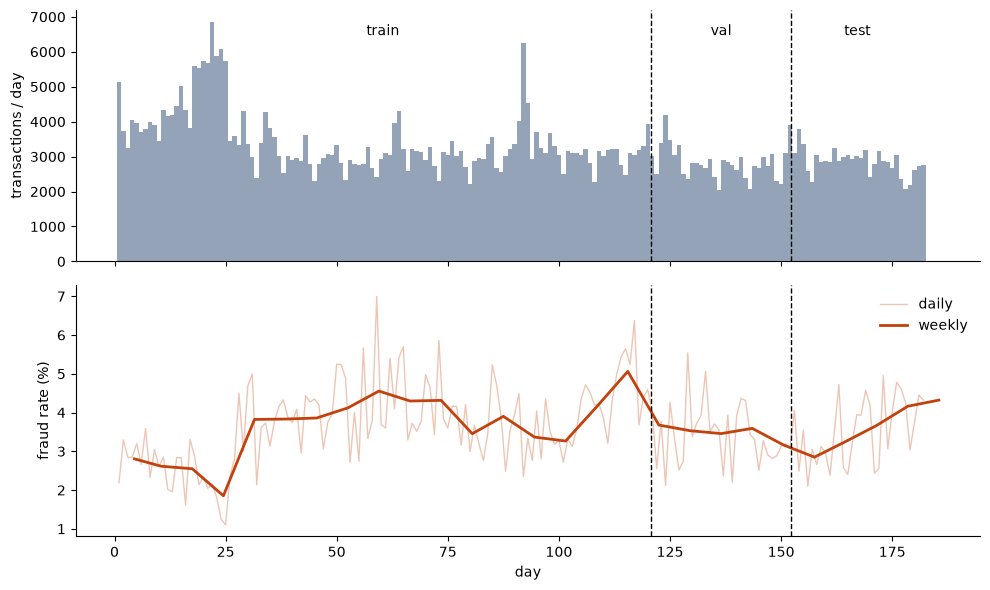

In [3]:
daily = (
    df.group_by("day")
    .agg(pl.len().alias("n"), pl.col("isFraud").mean().alias("fraud_rate"))
    .sort("day")
)
weekly = (
    df.with_columns((pl.col("day") // 7).alias("week"))
    .group_by("week")
    .agg(pl.col("isFraud").mean().alias("fraud_rate"), pl.col("day").min().alias("day"))
    .sort("week")
)
splits = time_split(df)
bounds = [splits.val["TransactionDT"].min() / 86400, splits.test["TransactionDT"].min() / 86400]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.bar(daily["day"], daily["n"], color="#94a3b8", width=1)
ax1.set_ylabel("transactions / day")
ax2.plot(daily["day"], daily["fraud_rate"] * 100, color=FRAUD, alpha=0.3, lw=1, label="daily")
ax2.plot(weekly["day"] + 3.5, weekly["fraud_rate"] * 100, color=FRAUD, lw=2, label="weekly")
ax2.set_ylabel("fraud rate (%)")
ax2.set_xlabel("day")
ax2.legend(frameon=False)
for ax in (ax1, ax2):
    for b in bounds:
        ax.axvline(b, color="black", ls="--", lw=1)
ax1.text(bounds[0] / 2, ax1.get_ylim()[1] * 0.9, "train", ha="center")
ax1.text(sum(bounds) / 2, ax1.get_ylim()[1] * 0.9, "val", ha="center")
ax1.text((bounds[1] + 182) / 2, ax1.get_ylim()[1] * 0.9, "test", ha="center")
plt.tight_layout()

In [4]:
pl.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [p.height for p in splits],
        "first_day": [p["day"].min() for p in splits],
        "last_day": [p["day"].max() for p in splits],
        "fraud_pct": [round(p["isFraud"].mean() * 100, 2) for p in splits],
    }
)

split,rows,first_day,last_day,fraud_pct
str,i64,i64,i64,f64
"""train""",413378,1,120,3.52
"""val""",88581,120,152,3.43
"""test""",88581,152,182,3.48


## Amounts
Fraud and legit amounts overlap heavily, so amount alone won't separate them. The largest transactions are all legit.

In [5]:
df.group_by("isFraud").agg(
    pl.col("TransactionAmt").median().alias("median"),
    pl.col("TransactionAmt").mean().round(2).alias("mean"),
    pl.col("TransactionAmt").quantile(0.99).alias("p99"),
    pl.col("TransactionAmt").max().alias("max"),
)

isFraud,median,mean,p99,max
i8,f64,f64,f64,f64
0,68.5,134.51,1104.0,31937.391
1,75.0,149.24,994.0,5191.0


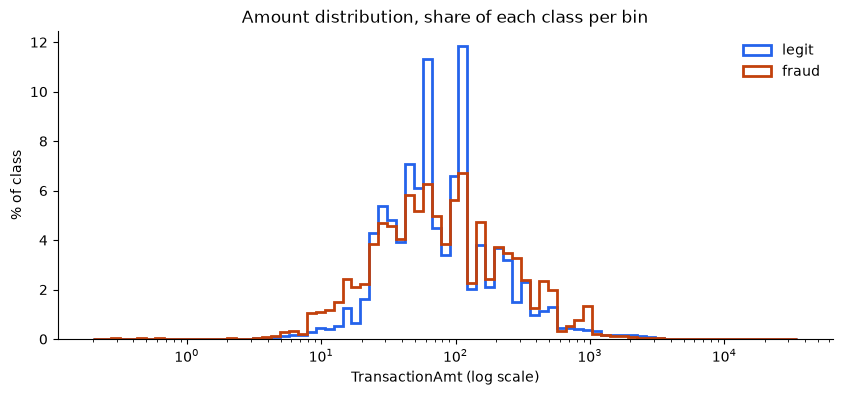

In [6]:
bins = np.logspace(np.log10(0.2), np.log10(35_000), 80)
for label, color, name in [(0, LEGIT, "legit"), (1, FRAUD, "fraud")]:
    amt = df.filter(pl.col("isFraud") == label)["TransactionAmt"].to_numpy()
    # Weights make each class sum to 100%. density=True would divide by bin width,
    # which inflates the narrow low-dollar bins on a log axis.
    plt.hist(
        amt,
        bins=bins,
        weights=np.full(len(amt), 100 / len(amt)),
        histtype="step",
        lw=2,
        color=color,
        label=name,
    )
plt.xscale("log")
plt.xlabel("TransactionAmt (log scale)")
plt.ylabel("% of class")
plt.legend(frameon=False)
plt.title("Amount distribution, share of each class per bin");

In [7]:
amount_band = (
    pl.col("TransactionAmt").cut([1, 5, 20, 50, 100, 500], left_closed=True).alias("amount_band")
)
df.group_by(amount_band).agg(
    pl.len().alias("n"),
    (pl.col("isFraud").mean() * 100).round(2).alias("fraud_pct"),
    (pl.col("isFraud").sum() / df["isFraud"].sum() * 100).round(1).alias("pct_of_all_fraud"),
).sort("amount_band")

amount_band,n,fraud_pct,pct_of_all_fraud
enum,u32,f64,f64
"""[-inf, 1)""",152,14.47,0.1
"""[1, 5)""",1176,5.1,0.3
"""[5, 20)""",25826,8.29,10.4
"""[20, 50)""",160361,3.28,25.4
"""[50, 100)""",160742,2.87,22.3
"""[100, 500)""",217959,3.4,35.9
"""[500, inf)""",24324,4.72,5.6


In [8]:
# ~10% of amounts have more than 2 decimal places, which suggests currency conversion.
odd_cents = ((pl.col("TransactionAmt") * 100).round(6) % 1).abs() > 1e-6
df.group_by(odd_cents.alias("more_than_2_decimals")).agg(
    pl.len(), pl.col("isFraud").mean().round(4)
)

more_than_2_decimals,len,isFraud
bool,u32,f64
false,528607,0.0254
true,61933,0.1172


## Missing values
Most columns are mostly empty. For tree models, *whether* a value is missing can itself be a signal.

435 columns | none missing: 21
>50% missing: 214 | >90% missing: 12


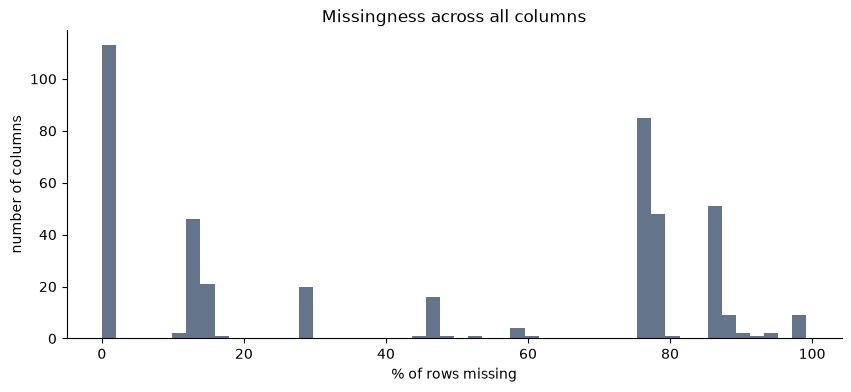

In [9]:
missing = (
    df.null_count()
    .transpose(include_header=True, header_name="column", column_names=["n_null"])
    .with_columns((pl.col("n_null") / df.height).alias("frac_null"))
    .sort("frac_null", descending=True)
)
frac = missing["frac_null"]
print(f"{df.width} columns | none missing: {(frac == 0).sum()}")
print(f">50% missing: {(frac > 0.5).sum()} | >90% missing: {(frac > 0.9).sum()}")
plt.hist(missing["frac_null"] * 100, bins=50, color="#64748b")
plt.xlabel("% of rows missing")
plt.ylabel("number of columns")
plt.title("Missingness across all columns");

## Fraud rate by category
Some simple categorical columns already separate fraud rates by 2× to 5×. These are the raw material for the rules baseline in Phase 2.

In [10]:
def rate_by(col, min_n=0):
    return (
        df.group_by(col)
        .agg(pl.len().alias("n"), (pl.col("isFraud").mean() * 100).round(2).alias("fraud_pct"))
        .filter(pl.col("n") >= min_n)
        .sort("fraud_pct", descending=True)
    )


rate_by("ProductCD")

ProductCD,n,fraud_pct
str,u32,f64
"""C""",68519,11.69
"""S""",11628,5.9
"""H""",33024,4.77
"""R""",37699,3.78
"""W""",439670,2.04


In [11]:
rate_by("DeviceType")

DeviceType,n,fraud_pct
str,u32,f64
"""mobile""",55645,10.17
"""desktop""",85165,6.52
null,449730,2.1


In [12]:
rate_by(pl.col("id_01").is_not_null().alias("has_identity_row"))

has_identity_row,n,fraud_pct
bool,u32,f64
true,144233,7.85
false,446307,2.09


In [13]:
rate_by("card6", min_n=100)

card6,n,fraud_pct
str,u32,f64
"""credit""",148986,6.68
null,1571,2.48
"""debit""",439938,2.43


In [14]:
rate_by("P_emaildomain", min_n=2000).head(8)

P_emaildomain,n,fraud_pct
str,u32,f64
"""outlook.com""",5096,9.46
"""hotmail.com""",45250,5.3
"""gmail.com""",228355,4.35
"""icloud.com""",6267,3.14
"""comcast.net""",7888,3.12
null,94456,2.95
"""live.com""",3041,2.76
"""anonymous.com""",36998,2.32


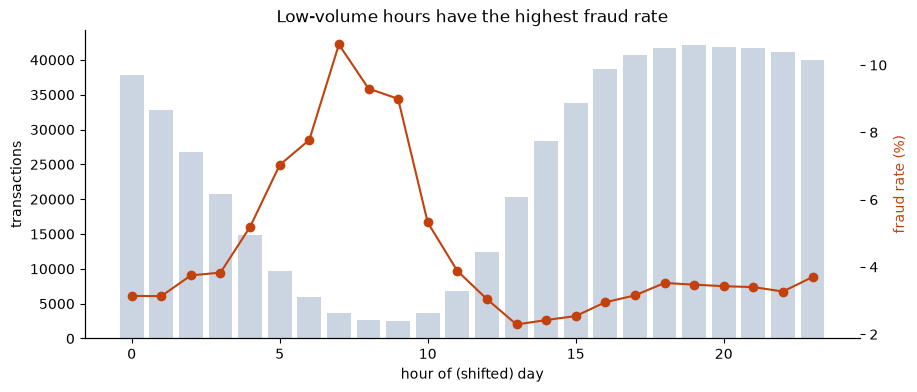

In [15]:
# Hour within the hidden reference day. The reference point is unknown,
# so "hour 7" is not necessarily 7am.
hourly = (
    df.with_columns(((pl.col("TransactionDT") % 86400) // 3600).alias("hour"))
    .group_by("hour")
    .agg(pl.len().alias("n"), pl.col("isFraud").mean().alias("fraud_rate"))
    .sort("hour")
)
fig, ax1 = plt.subplots()
ax1.bar(hourly["hour"], hourly["n"], color="#cbd5e1")
ax1.set_ylabel("transactions")
ax1.set_xlabel("hour of (shifted) day")
ax2 = ax1.twinx()
ax2.plot(hourly["hour"], hourly["fraud_rate"] * 100, color=FRAUD, marker="o")
ax2.set_ylabel("fraud rate (%)", color=FRAUD)
plt.title("Low-volume hours have the highest fraud rate");